# RQ2: Completeness analysis

Reproduces every number in `Findings.tex` § *RQ2*: per-category GDPR coverage, the
all-18-categories completeness rate, top-5 complete first parties (by Tranco rank), top-5
complete third parties (by prevalence), and the `fkgl_gdpr_v4` figure.

Inputs are read from `data/dataset.tar.gz` (extracted on first run). All denominators are
the canonical 3,067 qualifying first parties / 1,122 qualifying third parties from
`canonical_qualifying.json`.


## 1. Setup### 1.1 Decompress the bundled dataset

In [1]:
import tarfile
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR  = REPO_ROOT / 'data' / 'raw'
BUNDLE    = REPO_ROOT / 'data' / 'dataset.tar.gz'
DATA_DIR.mkdir(parents=True, exist_ok=True)
if (DATA_DIR / 'gdpr_coverage_per_policy.json').exists():
    print(f'Already extracted at {DATA_DIR}')
else:
    print(f'Extracting {BUNDLE.name} ...')
    with tarfile.open(BUNDLE, 'r:gz') as tf:
        tf.extractall(DATA_DIR)
    print('Done.')


Already extracted at <repo>/data/raw


### 1.2 Imports and the canonical filter

All denominators come from `canonical_qualifying.json` so that this notebook stays
consistent with the rest of the repository.


In [2]:
import json, csv
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

canon = json.load(open(DATA_DIR / 'canonical_qualifying.json'))
fp_qualifying = {e.lower() for e in canon['fp_qualifying_etld1']}
tp_qualifying = {e.lower() for e in canon['tp_qualifying_etld1']}
n_fp_canon = canon['fp_count']
n_tp_canon = canon['tp_count']
print(f'qualifying FPs: {n_fp_canon:,}')
print(f'qualifying TPs: {n_tp_canon:,}')


qualifying FPs: 3,067
qualifying TPs: 1,122


### 1.3 Per-policy GDPR-category coverage

`gdpr_coverage_per_policy.json` was produced by running the GDPR RoBERTa classifier on
every clause of every qualifying policy and recording the union of categories the classifier
flagged. A policy is *complete* if it covers all 18 categories of GDPR Articles 13/14.


In [3]:
cov = json.load(open(DATA_DIR / 'gdpr_coverage_per_policy.json'))
fp_cov = {k.lower(): set(v) for k, v in cov['fp'].items() if k.lower() in fp_qualifying}
tp_cov = {k.lower(): set(v) for k, v in cov['tp'].items() if k.lower() in tp_qualifying}
print(f'FP policies with coverage data: {len(fp_cov):,}')
print(f'TP policies with coverage data: {len(tp_cov):,}')


FP policies with coverage data: 2,795
TP policies with coverage data: 1,100


## 2. Per-category coverage rates (`tab:rq2-coverage`)

Share of qualifying FP and TP policies that disclose each of the 18 GDPR transparency
categories at least once. Sorted by FP coverage, descending.


In [4]:
GDPR_CATS = sorted({c for cats in fp_cov.values() for c in cats} |
                   {c for cats in tp_cov.values() for c in cats})

rows = []
for c in GDPR_CATS:
    fp = sum(1 for v in fp_cov.values() if c in v) / n_fp_canon * 100
    tp = sum(1 for v in tp_cov.values() if c in v) / n_tp_canon * 100
    rows.append({'category': c, 'FP%': round(fp, 1), 'TP%': round(tp, 1)})
df = pd.DataFrame(rows).sort_values('FP%', ascending=False).reset_index(drop=True)
print(df.to_string(index=False))


             category  FP%  TP%
   Processing Purpose 90.9 96.7
      Data Categories 89.5 92.2
      Safeguards Copy 89.0 93.2
      Data Recipients 87.1 87.8
   Controller Contact 85.4 88.9
    Right to Restrict 79.9 80.4
      Right to Access 78.9 77.8
      Right to Object 78.3 84.8
       Right to Erase 77.4 79.1
       Source of Data 74.0 73.2
       Storage Period 73.0 76.8
Provision Requirement 69.1 57.0
    Adequacy Decision 58.1 62.6
     Withdraw Consent 56.5 57.7
      Lodge Complaint 46.7 51.4
          DPO Contact 38.7 39.4
 Right to Portability 33.9 39.9
            Profiling 25.7 27.5


## 3. All-18-categories completeness

The headline number reported in the Conclusion: the share of qualifying policies that cover
all 18 GDPR transparency categories.


In [5]:
fp_complete = sum(1 for v in fp_cov.values() if len(v) >= 18)
tp_complete = sum(1 for v in tp_cov.values() if len(v) >= 18)
print(f'FP complete : {fp_complete:>4} / {n_fp_canon:,}  ({fp_complete/n_fp_canon*100:.1f}%)')
print(f'TP complete : {tp_complete:>4} / {n_tp_canon:,}  ({tp_complete/n_tp_canon*100:.1f}%)')


FP complete :  206 / 3,067  (6.7%)
TP complete :   52 / 1,122  (4.6%)


## 4. Top-5 complete first parties (by Tranco rank)

Of the qualifying FPs that cover all 18 categories, the five highest-ranked Tranco sites.


In [6]:
rows = [json.loads(ln) for ln in open(DATA_DIR / 'results.jsonl')]
rank_by = {(r.get('site_etld1') or '').lower(): r.get('rank')
           for r in rows if r.get('site_etld1') and r.get('rank') is not None}
category_by = {(r.get('site_etld1') or '').lower(): r.get('main_category') for r in rows}
complete_fps = [(et, rank_by.get(et), category_by.get(et))
                for et, cats in fp_cov.items()
                if len(cats) >= 18 and rank_by.get(et)]
complete_fps.sort(key=lambda x: x[1])
df_fp = pd.DataFrame(complete_fps[:5], columns=['domain', 'tranco_rank', 'category'])
print(df_fp.to_string(index=False))


        domain  tranco_rank           category
   netflix.com           33      Entertainment
        bit.ly           92         Technology
   nytimes.com          160       News & Media
salesforce.com          201 Business & Finance
       bbc.com          211       News & Media


## 5. Top-5 complete third parties (by prevalence)

Among complete TPs, the five most prevalent. Prevalence = share of qualifying first parties
(out of 3,067) that embed the third party at least once during crawl.


In [7]:
tp_fp_count = Counter()
for r in rows:
    if r.get('home_ok') is not True: continue
    seen = set()
    for tp in (r.get('third_parties') or []):
        if isinstance(tp, dict):
            et = (tp.get('third_party_etld1') or '').lower()
            if et: seen.add(et)
    for et in seen:
        tp_fp_count[et] += 1
complete_tps = sorted([(et, tp_fp_count.get(et, 0)) for et, cats in tp_cov.items() if len(cats) >= 18],
                       key=lambda x: -x[1])
df_tp = pd.DataFrame(
    [(et, n, round(n/n_fp_canon*100, 1)) for et, n in complete_tps[:5]],
    columns=['domain', '# embedding FPs', 'prevalence (%)'],
)
print(df_tp.to_string(index=False))


        domain  # embedding FPs  prevalence (%)
        mrf.io              162             5.3
optimizely.com              116             3.8
   newsroom.bi              113             3.7
quantserve.com              106             3.5
quantcount.com               98             3.2


## 6. Figure: `fkgl_gdpr_v4`

Median GDPR-category coverage as a function of policy readability (Flesch-Kincaid Grade
Level), separately for FP and TP. Backed by `wordcount_fkgl_gdpr_v4.json`, which is bundled
in `data/dataset.tar.gz`.


wrote <repo>/notebooks/figures/wordcount_gdpr_v4.pdf
wrote <repo>/notebooks/figures/wordcount_gdpr_v4_iqr.pdf
wrote <repo>/notebooks/figures/fkgl_gdpr_v4.pdf
wrote <repo>/notebooks/figures/fkgl_gdpr_v4_iqr.pdf


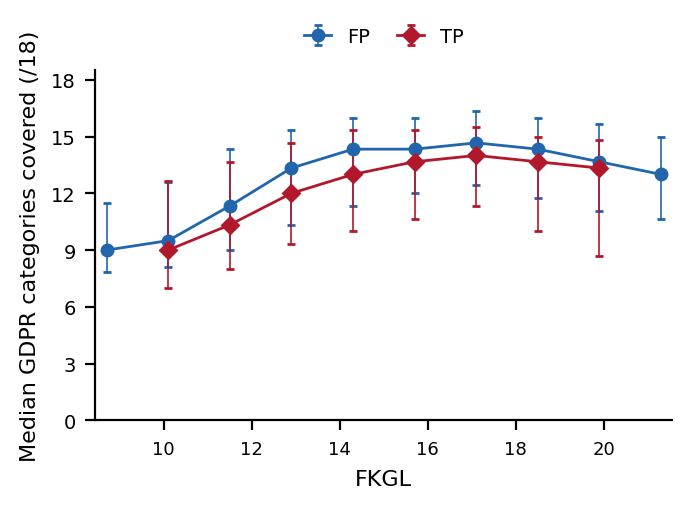

In [8]:
# Figure: fkgl_gdpr_v4 — produced by code/figures/figure_wordcount_fkgl_gdpr_v4.py
import subprocess
from IPython.display import Image, display
subprocess.run(['python', str(REPO_ROOT / 'code/figures/figure_wordcount_fkgl_gdpr_v4.py'),
                '--data-json', str(DATA_DIR / 'wordcount_fkgl_gdpr_v4.json'),
                '--out-dir',   str(REPO_ROOT / 'notebooks' / 'figures')],
               check=True)
display(Image(str(REPO_ROOT / 'notebooks' / 'figures' / 'fkgl_gdpr_v4.png'), width=900))


## 7. Sanity check — paper numbers


In [9]:
checks = {
    'FP qualifying':                       (n_fp_canon, 3067),
    'TP qualifying':                       (n_tp_canon, 1122),
    'FP complete (count)':                 (fp_complete, 206),
    'TP complete (count)':                 (tp_complete, 52),
    'FP complete (percentage)':            (round(fp_complete/n_fp_canon*100, 1), 6.7),
    'TP complete (percentage)':            (round(tp_complete/n_tp_canon*100, 1), 4.6),
}
ok = True
for k, (v, expected) in checks.items():
    match = abs(v - expected) < 0.05 if isinstance(v, float) else v == expected
    print(f'  {k:30s}  {v}   (paper: {expected}, {"OK" if match else "MISMATCH"})')
    if not match: ok = False
print('\n' + ('PASSED' if ok else 'FAILED'))


  FP qualifying                   3067   (paper: 3067, OK)
  TP qualifying                   1122   (paper: 1122, OK)
  FP complete (count)             206   (paper: 206, OK)
  TP complete (count)             52   (paper: 52, OK)
  FP complete (percentage)        6.7   (paper: 6.7, OK)
  TP complete (percentage)        4.6   (paper: 4.6, OK)

PASSED
